<a href="https://colab.research.google.com/github/kimngandinh/Test/blob/main/Survey.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pingouin -q

import re
import pandas as pd
import numpy as np
import pingouin as pg
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

try:
    from google.colab import drive
    drive.mount('/content/drive')
    PATH = '/content/drive/MyDrive/Thesis Data/survey_data.csv'
except Exception:
    PATH = 'survey_data.csv'      # adjust if needed

df = pd.read_csv(PATH)
print(f"Loaded {len(df)} responses, {len(df.columns)} columns")

# Map Likert items by the start of the column name
LIKERT = {
    'SC':    ['SC1', 'SC2', 'SC3', 'SC4', 'SC5'],
    'OU':    ['OU1', 'OU2', 'OU3', 'OU4', 'OU5'],
    'AT':    ['AT1.', 'AT2.', 'AT3.', 'AT4.', 'AT5.', 'AT6.'],     # owner branch
    'AT_EU': ['AT1_EU', 'AT2_EU', 'AT3_EU', 'AT4_EU', 'AT5_EU'],   # employee branch
    'AI':    ['AI1.', 'AI2.', 'AI3.', 'AI4.'],
}
ITEMS = {k: [it.replace('.', '') for it in v] for k, v in LIKERT.items()}

def _match(prefix):
    hits = [c for c in df.columns if c.strip().startswith(prefix)]
    return hits[0] if hits else None

num = pd.DataFrame()
for v in LIKERT.values():
    for it in v:
        col = _match(it)
        if col is not None:
            num[it.replace('.', '')] = pd.to_numeric(df[col], errors='coerce')

# Split by role
ROLE_COL = next(c for c in df.columns if 'vai trò' in c.lower())
owner = df[ROLE_COL].astype(str).str.contains('Chủ|Quản lý', na=False, regex=True)
emp   = df[ROLE_COL].astype(str).str.contains('Thu ngân|Nhân viên', na=False, regex=True)
print(f"Owner (decision-maker): {owner.sum()}  |  Employee (end-user): {emp.sum()}")

# Composite scores (mean of items in each construct)
num['SC_score'] = num[ITEMS['SC']].mean(axis=1)
num['OU_score'] = num[ITEMS['OU']].mean(axis=1)
num['AI_score'] = num[ITEMS['AI']].mean(axis=1)
num['AT_score'] = np.nan
num.loc[owner, 'AT_score'] = num.loc[owner, ITEMS['AT']].mean(axis=1)
num.loc[emp,   'AT_score'] = num.loc[emp,   ITEMS['AT_EU']].mean(axis=1)

# Helper to find a demographic/validation column by its question code (1.1, 2.3, ...)
def col_by_code(code):
    pat = re.compile(r'^' + re.escape(code) + r'(?!\d)')
    hits = [c for c in df.columns if pat.match(c.strip())]
    return hits[0] if hits else None

def freq(code, label, multiselect=False):
    """Print a frequency table for one categorical question."""
    col = col_by_code(code)
    if col is None:
        print(f"[{code}] COLUMN NOT FOUND - skipped ({label})")
        return
    print(f"\n[{code}] {label}  (N={df[col].notna().sum()})")
    s = df[col].dropna().astype(str)
    if multiselect:                       # multi-answer question: split on commas
        s = s.str.split(',').explode().str.strip()
    vc = s.value_counts()
    pct = (vc / len(df[col].dropna()) * 100).round(1)
    for k in vc.index:
        print(f"    {vc[k]:3d} ({pct[k]:4.1f}%)  {k[:70]}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 478.4 kB/s eta 0:00:00
Mounted at /content/drive
Loaded 75 responses, 48 columns
Owner (decision-maker): 30  |  Employee (end-user): 45


In [ ]:
# CELL 1 - 3.2.1 SAMPLE DESCRIPTIVE TABLE (Table 4.1), English labels
# Requires CELL 0 (df, col_by_code) to have run first.

# (vn_value -> en_label), listed in the display order we want each variable to appear
VARS = [
 ('Gender','1.2',[('Nam','Male'),('Nữ','Female'),('Không muốn nêu cụ thể','Prefer not to say')]),
 ('Age group','1.1',[('Dưới 25 tuổi','Under 25'),('Từ 18 đến 24 tuổi','18-24'),
    ('Từ 25 đến 34 tuổi','25-34'),('Từ 35 đến 44 tuổi','35-44'),('Từ 45 đến 54 tuổi','45-54')]),
 ('Business sub-category','1.3',[('Quán cà phê hoặc đồ uống','Cafe / beverages'),
    ('Tiệm bánh','Bakery'),('Rau củ quả tươi hoặc tạp hóa','Fresh produce / grocery'),
    ('Thịt hoặc hải sản tươi sống','Fresh meat / seafood'),
    ('Đồ ăn nhanh, bán tại chỗ/giao hàng hoặc cơm trưa văn phòng','Fast food / takeaway / office lunch'),
    ('Nhà hàng kinh doanh đa dạng mặt hàng','Multi-category restaurant')]),
 ('Years of operation','1.4',[('Dưới 1 năm','Under 1 year'),('Từ 1 đến 3 năm','1-3 years'),
    ('Từ 3 đến 5 năm','3-5 years'),('Từ 5 đến 10 năm','5-10 years'),('Trên 10 năm','Over 10 years')]),
 ('Pricing decision authority','1.5',[('Chủ cửa hàng/Quản lý','Owner / manager'),
    ('Nhân viên/Thu ngân','Staff / cashier')]),   # NOTE: verify this column; it mirrors Role
 ('Daily transaction volume','1.6',[('Dưới 50 giao dịch','Under 50'),
    ('Từ 50 đến 150 giao dịch','50-150'),('Từ 150 đến 300 giao dịch','150-300'),
    ('Trên 500 giao dịch','Over 500')]),
 ('Daily waste (estimated)','1.9',[('Dưới 5%','Under 5%'),('Từ 5% đến 15%','5-15%'),
    ('Trên 15%','Over 15%'),('Tôi không chắc chắn','Not sure')]),
 ('End-of-day discount','1.10',[('Chưa bao giờ','Never'),('Hiếm khi','Rarely'),
    ('Có, thỉnh thoảng','Yes, occasionally'),('Có, thường xuyên','Yes, frequently')]),
]

rows, unmapped = [], []
for name, code, mapping in VARS:
    col = col_by_code(code)
    if col is None:
        print(f"MISSING COLUMN for {code} ({name})"); continue
    s = df[col].dropna().astype(str).str.strip()
    base = len(s)
    mapped = set(v for v, _ in mapping)
    for v in s.unique():
        if v not in mapped:
            unmapped.append((name, code, repr(v)))      # values you still need to translate
    first = True
    for vn, en in mapping:
        n = int((s == vn).sum())
        rows.append([name if first else '', en, n, round(n / base * 100, 1)])
        first = False

table41 = pd.DataFrame(rows, columns=['Variable name', 'Sample characteristics', 'n', '%'])
print("TABLE 4.1  DESCRIPTIVE STATISTICS OF THE SAMPLE (N=75)")
print(table41.to_string(index=False))
if unmapped:
    print("\nUNMAPPED VALUES (add them to the mapping above):")
    for u in unmapped: print("  ", u)

# Multi-response variables (a respondent can pick several; % is of respondents and sums >100%)
MULTI = [
 ('POS software in use','1.7',[('KiotViet','KiotViet'),('iPOS','iPOS'),('Sapo','Sapo'),
    ('Misa CukCuk','Misa CukCuk'),('POS365','POS365'),('Không sử dụng phần mềm POS','No POS (manual)')]),
 ('Advanced POS features used','1.8',[('tính năng cơ bản','Basic only (payment & receipts)'),
    ('Quản lý tồn kho','Inventory management'),
    ('Tích hợp với các nền tảng giao hàng','Delivery platform integration'),
    ('Báo cáo doanh thu','Revenue reports'),
    ('Quản lý chương trình khuyến mãi','Promotion / voucher management'),
    ('Phân tích dữ liệu khách hàng','Customer data analytics')]),
]
mrows = []
for name, code, opts in MULTI:
    col = col_by_code(code)
    if col is None:
        print(f"MISSING COLUMN for {code} ({name})"); continue
    s = df[col].dropna().astype(str)
    base = len(s)
    first = True
    for vn, en in opts:
        n = int(s.str.contains(re.escape(vn)).sum())     # substring match avoids comma-split errors
        mrows.append([name if first else '', en, n, round(n / base * 100, 1)])
        first = False

table_multi = pd.DataFrame(mrows, columns=['Variable name', 'Option', 'n', '%'])
print("\nTABLE 4.2  OPERATIONAL CHARACTERISTICS (multi-response; % of respondents, sums >100%)")
print(table_multi.to_string(index=False))

# Export to CSV (opens in Excel/Word)
table41.to_csv('table_4_1_sample.csv', index=False, encoding='utf-8-sig')
table_multi.to_csv('table_4_2_operational.csv', index=False, encoding='utf-8-sig')

TABLE 4.1  DESCRIPTIVE STATISTICS OF THE SAMPLE (N=75)
             Variable name              Sample characteristics  n    %
                    Gender                                Male 35 46.7
                                                        Female 39 52.0
                                             Prefer not to say  1  1.3
                 Age group                            Under 25  4  5.3
                                                         18-24  8 10.7
                                                         25-34 22 29.3
                                                         35-44 15 20.0
                                                         45-54 26 34.7
     Business sub-category                    Cafe / beverages 34 45.3
                                                        Bakery 16 21.3
                                       Fresh produce / grocery 10 13.3
                                          Fresh meat / seafood  8 10.7
                      

In [ ]:
# CELL 2 - 3.2.2 VALIDATION OF SIMULATION FINDINGS vs MERCHANT REALITY
print("=" * 70); print("3.2.2  VALIDATION OF SIMULATION FINDINGS"); print("=" * 70)
freq('2.1', 'Prior awareness of dynamic pricing')
freq('2.2', 'Does 36.23% baseline waste match reality')
freq('2.3', 'Is the waste reduction persuasive')
freq('2.4', 'Closest product category')
freq('2.5', 'Is the profit increase plausible')
freq('2.6', 'Did it reduce worry about simulation error')
freq('2.7', 'Importance of profitable-transaction stability')
freq('2.8', 'Most convincing chart', multiselect=True)

3.2.2  VALIDATION OF SIMULATION FINDINGS

[2.1] Prior awareness of dynamic pricing  (N=75)
     21 (28.0%)  Biết khá rõ qua tin tức hoặc đồng nghiệp
     20 (26.7%)  Biết rất rõ (Đã từng tìm hiểu kỹ hoặc áp dụng)
     19 (25.3%)  Chưa từng nghe đến
     11 (14.7%)  Biết sơ qua (Từng nghe loáng thoáng)
      3 ( 4.0%)  Có nghe qua nhưng chưa hiểu chi tiết
      1 ( 1.3%)  Biết sơ qua

[2.2] Does 36.23% baseline waste match reality  (N=75)
     41 (54.7%)  Tôi không chắc chắn
     20 (26.7%)  Cao hơn thực tế cửa hàng tôi
     11 (14.7%)  Đúng với thực tế cửa hàng tôi
      3 ( 4.0%)  Thấp hơn thực tế cửa hàng tôi

[2.3] Is the waste reduction persuasive  (N=75)
     46 (61.3%)  Bình thường
     25 (33.3%)  Khá thuyết phục
      4 ( 5.3%)  Chưa thuyết phục

[2.4] Closest product category  (N=75)
     27 (36.0%)  Beverages (đồ uống)
     14 (18.7%)  Bakery (bánh ngọt, bánh mì)
     10 (13.3%)  Produce (rau củ quả tươi)
      7 ( 9.3%)  Meat (thịt tươi)
      6 ( 8.0%)  Ready-to-Eat (đồ ăn 

In [ ]:
# CELL 2 - 3.2.2 VALIDATION OF SIMULATION FINDINGS, English labels
# Requires CELL 0 (df, col_by_code). Near-duplicate options are merged by English label.

VAL_VARS = [
 ('Prior awareness of dynamic pricing','2.1',[
    ('Biết rất rõ (Đã từng tìm hiểu kỹ hoặc áp dụng)','Very aware (researched or applied)'),
    ('Biết khá rõ qua tin tức hoặc đồng nghiệp','Fairly aware (via news/colleagues)'),
    ('Biết sơ qua (Từng nghe loáng thoáng)','Vaguely aware (heard in passing)'),
    ('Biết sơ qua','Vaguely aware (heard in passing)'),
    ('Có nghe qua nhưng chưa hiểu chi tiết','Heard of it but limited understanding'),
    ('Chưa từng nghe đến','Never heard of it')]),
 ('Does 36.23% baseline waste match reality','2.2',[
    ('Đúng với thực tế cửa hàng tôi','Matches my store'),
    ('Cao hơn thực tế cửa hàng tôi','Higher than my store'),
    ('Thấp hơn thực tế cửa hàng tôi','Lower than my store'),
    ('Tôi không chắc chắn','Not sure')]),
 ('Is the waste reduction persuasive','2.3',[
    ('Khá thuyết phục','Fairly persuasive'),
    ('Bình thường','Neutral'),
    ('Chưa thuyết phục','Not persuasive')]),
 ('Closest product category','2.4',[
    ('Beverages (đồ uống)','Beverages'),
    ('Bakery (bánh ngọt, bánh mì)','Bakery'),
    ('Produce (rau củ quả tươi)','Produce'),
    ('Meat (thịt tươi)','Meat'),
    ('Ready-to-Eat (đồ ăn sẵn, cơm văn phòng)','Ready-to-Eat'),
    ('Deli (đồ chế biến sẵn)','Deli'),
    ('Seafood (hải sản)','Seafood'),
    ('Dairy (sản phẩm sữa)','Dairy')]),
 ('Is the profit increase plausible','2.5',[
    ('Hợp lý và khả thi','Reasonable and feasible'),
    ('Hợp lý nhưng cao hơn kỳ vọng','Reasonable but higher than expected'),
    ('Bình thường','Neutral'),
    ('Tôi không chắc chắn','Not sure')]),
 ('Did it reduce worry about simulation error','2.6',[
    ('Giảm lo lắng rất nhiều','Greatly reduced my concern'),
    ('Giảm lo lắng khá nhiều','Considerably reduced my concern'),
    ('Bình thường','Neutral')]),
 ('Importance of profitable-transaction stability','2.7',[
    ('Rất quan trọng, vì sự ổn định lợi nhuận là ưu tiên hàng đầu','Very important (stability is top priority)'),
    ('Khá quan trọng','Fairly important'),
    ('Bình thường','Neutral'),
    ('Không quan trọng lắm vì tôi tập trung vào lợi nhuận trung bình hơn','Not very important (focus on average profit)'),
    ('Không quan trọng','Not important')]),
]

rows, unmapped = [], []
for label, code, mapping in VAL_VARS:
    col = col_by_code(code)
    if col is None:
        print(f"MISSING COLUMN for {code} ({label})"); continue
    s = df[col].dropna().astype(str).str.strip()
    base = len(s)
    mapped = set(v for v, _ in mapping)
    for v in s.unique():
        if v not in mapped: unmapped.append((label, code, repr(v)))
    agg = {}                                   # merge near-duplicate options by English label
    for vn, en in mapping:
        agg[en] = agg.get(en, 0) + int((s == vn).sum())
    first = True
    for en in dict.fromkeys(e for _, e in mapping):     # preserve declared order
        n = agg[en]
        rows.append([label if first else '', en, n, round(n / base * 100, 1)])
        first = False

val_table = pd.DataFrame(rows, columns=['Validation item', 'Response', 'n', '%'])
print("3.2.2  VALIDATION OF SIMULATION FINDINGS (N=75)")
print(val_table.to_string(index=False))
if unmapped:
    print("\nUNMAPPED (add to the mapping):")
    for u in unmapped: print("  ", u)

# 2.8 most convincing chart (multi-response; % of respondents, sums >100%)
CHARTS = [('Biểu đồ 1','Chart 1 (static waste distribution)'),
          ('Biểu đồ 2','Chart 2 (dynamic waste improvement)'),
          ('Biểu đồ 3','Chart 3 (category profit comparison)'),
          ('Biểu đồ 4','Chart 4 (robustness curve)'),
          ('Biểu đồ 5','Chart 5 (batch profitability distribution)')]
col = col_by_code('2.8'); s = df[col].dropna().astype(str); base = len(s)
print(f"\n[2.8] Most convincing chart (multi-response, base N={base}, sums >100%)")
for vn, en in CHARTS:
    n = int(s.str.contains(re.escape(vn)).sum())
    print(f"   {n:3d} ({n/base*100:4.1f}%)  {en}")

val_table.to_csv('table_3_2_2_validation.csv', index=False, encoding='utf-8-sig')
print("\nSaved: table_3_2_2_validation.csv")

3.2.2  VALIDATION OF SIMULATION FINDINGS (N=75)
                               Validation item                                     Response  n    %
            Prior awareness of dynamic pricing           Very aware (researched or applied) 20 26.7
                                                         Fairly aware (via news/colleagues) 21 28.0
                                                           Vaguely aware (heard in passing) 12 16.0
                                                      Heard of it but limited understanding  3  4.0
                                                                          Never heard of it 19 25.3
      Does 36.23% baseline waste match reality                             Matches my store 11 14.7
                                                                       Higher than my store 20 26.7
                                                                        Lower than my store  3  4.0
                                                    

In [ ]:
# CELL 3b - 3.2.3 RELIABILITY TABLES (Image-3 / Stata 'alpha' style)
import numpy as np

def avg_interitem_cov(f):
    cov = f.cov().values
    off = cov[~np.eye(cov.shape[0], dtype=bool)]   # off-diagonal covariances
    return off.mean()

def reliability_table(items, title, mask=None):
    f = num[items] if mask is None else num.loc[mask, items]
    f = f.dropna()
    a = pg.cronbach_alpha(data=f)[0]
    print(f"\n{title}")
    print(f"  Average interitem covariance : {avg_interitem_cov(f):.4f}")
    print(f"  Number of items in the scale : {f.shape[1]}")
    print(f"  Scale reliability coefficient: {a:.4f}")

reliability_table(['SC1','SC2','SC3','SC4','SC5'], "Table 4.4  System Compatibility")
reliability_table(['OU1','OU2','OU3','OU4','OU5'], "Table 4.5  Operational Usability")
reliability_table(['AI1','AI2','AI3','AI4'], "Table 4.6  Adoption Intention")
reliability_table(['AT1','AT2','AT3','AT4','AT5','AT6'], "Table 4.7  Algorithm Trust - Decision-makers", owner)
reliability_table(['AT1_EU','AT2_EU','AT3_EU','AT4_EU','AT5_EU'], "Table 4.8  Algorithm Trust - End-users", emp)


Table 4.4  System Compatibility
  Average interitem covariance : 0.6228
  Number of items in the scale : 5
  Scale reliability coefficient: 0.7814

Table 4.5  Operational Usability
  Average interitem covariance : 0.9150
  Number of items in the scale : 5
  Scale reliability coefficient: 0.8624

Table 4.6  Adoption Intention
  Average interitem covariance : 0.7948
  Number of items in the scale : 4
  Scale reliability coefficient: 0.8141

Table 4.7  Algorithm Trust - Decision-makers
  Average interitem covariance : 0.4130
  Number of items in the scale : 6
  Scale reliability coefficient: 0.6929

Table 4.8  Algorithm Trust - End-users
  Average interitem covariance : 0.0650
  Number of items in the scale : 5
  Scale reliability coefficient: 0.2193


In [ ]:
# CELL 4 - 3.2.4 ASSESSMENT OF SYSTEM COMPATIBILITY
print("=" * 70); print("3.2.4  SYSTEM COMPATIBILITY"); print("=" * 70)
d = num[ITEMS['SC']].describe().T[['count', 'mean', 'std', 'min', 'max']]
d['count'] = d['count'].astype(int); print(d.round(3).to_string())
print(f"\nComposite SC_score: mean={num['SC_score'].mean():.3f}, SD={num['SC_score'].std():.3f}")

3.2.4  SYSTEM COMPATIBILITY
     count   mean    std  min  max
SC1     75  3.080  1.421  1.0  5.0
SC2     75  2.920  1.239  1.0  5.0
SC3     75  3.027  1.524  1.0  5.0
SC4     75  2.880  1.185  1.0  5.0
SC5     75  3.027  0.434  2.0  4.0

Composite SC_score: mean=2.987, SD=0.893


In [ ]:
# CELL 5 - 3.2.5 ASSESSMENT OF OPERATIONAL USABILITY
# NOTE: the draft mislabels 3.2.5 as "System Compatibility"; it should be Operational Usability.
print("=" * 70); print("3.2.5  OPERATIONAL USABILITY"); print("=" * 70)
d = num[ITEMS['OU']].describe().T[['count', 'mean', 'std', 'min', 'max']]
d['count'] = d['count'].astype(int); print(d.round(3).to_string())
print(f"\nComposite OU_score: mean={num['OU_score'].mean():.3f}, SD={num['OU_score'].std():.3f}")

3.2.5  OPERATIONAL USABILITY
     count   mean    std  min  max
OU1     75  3.067  1.339  1.0  5.0
OU2     75  3.147  1.312  1.0  5.0
OU3     75  3.027  1.162  1.0  5.0
OU4     75  3.107  1.279  1.0  5.0
OU5     75  3.147  1.312  1.0  5.0

Composite OU_score: mean=3.099, SD=1.030


In [ ]:
# CELL 6 - 3.2.6 ASSESSMENT OF ALGORITHM TRUST
print("=" * 70); print("3.2.6  ALGORITHM TRUST"); print("=" * 70)
print("\n[Owner branch - 6 items]")
d = num.loc[owner, ITEMS['AT']].describe().T[['count', 'mean', 'std', 'min', 'max']]
d['count'] = d['count'].astype(int); print(d.round(3).to_string())
print("\n[Employee branch - 5 items]   (NOTE: AT_EU reliability failed, alpha=0.22)")
d = num.loc[emp, ITEMS['AT_EU']].describe().T[['count', 'mean', 'std', 'min', 'max']]
d['count'] = d['count'].astype(int); print(d.round(3).to_string())
print(f"\nAT_score owner: mean={num.loc[owner,'AT_score'].mean():.3f}, SD={num.loc[owner,'AT_score'].std():.3f}")
print(f"AT_score emp:   mean={num.loc[emp,'AT_score'].mean():.3f}, SD={num.loc[emp,'AT_score'].std():.3f}")

3.2.6  ALGORITHM TRUST

[Owner branch - 6 items]
     count   mean    std  min  max
AT1     30  3.467  1.252  1.0  5.0
AT2     30  3.267  1.258  1.0  5.0
AT3     30  3.633  1.159  1.0  5.0
AT4     30  3.200  1.324  1.0  5.0
AT5     30  3.333  1.155  1.0  5.0
AT6     30  3.400  1.221  1.0  5.0

[Employee branch - 5 items]   (NOTE: AT_EU reliability failed, alpha=0.22)
        count   mean    std  min  max
AT1_EU     45  3.356  1.069  1.0  5.0
AT2_EU     45  3.467  1.079  2.0  5.0
AT3_EU     45  3.067  1.136  1.0  5.0
AT4_EU     45  3.289  1.199  1.0  5.0
AT5_EU     45  3.489  1.036  1.0  5.0

AT_score owner: mean=3.383, SD=0.772
AT_score emp:   mean=3.333, SD=0.544


In [ ]:
# CELL 7 - 3.2.7 ADOPTION INTENTION & PREDICTORS (OLS, split by role)
print("=" * 70); print("3.2.7  ADOPTION INTENTION & PREDICTORS"); print("=" * 70)

d = num[ITEMS['AI']].describe().T[['count', 'mean', 'std', 'min', 'max']]
d['count'] = d['count'].astype(int)
print("\nAdoption Intention item-level:"); print(d.round(3).to_string())
print(f"Composite AI_score: mean={num['AI_score'].mean():.3f}, SD={num['AI_score'].std():.3f}")

def run_ols(mask, predictors, label):
    d = num.loc[mask, predictors + ['AI_score']].dropna()
    if len(d) < 10:
        print(f"\n{label}: N={len(d)} too small."); return
    m = sm.OLS(d['AI_score'], sm.add_constant(d[predictors])).fit()
    print(f"\n--- {label}  (N={int(m.nobs)}) ---")
    print(f"R2={m.rsquared:.3f} | adj-R2={m.rsquared_adj:.3f} | F p={m.f_pvalue:.4f}")
    for p in predictors:
        sig = "significant (p<.05)" if m.pvalues[p] < 0.05 else "n.s."
        print(f"  {p:9s} beta={m.params[p]:+.3f}  p={m.pvalues[p]:.3f}  -> {sig}")

print("\n[Green threshold m=3: N > 74]")
# Owner: full model (AT owner scale is borderline but usable)
run_ols(owner, ['SC_score', 'OU_score', 'AT_score'], "OWNER: AI ~ SC + OU + AT")
# Employee: AT_EU failed reliability, so report the model WITHOUT AT as primary,
# and the full model only for completeness.
run_ols(emp, ['SC_score', 'OU_score'], "EMPLOYEE (primary): AI ~ SC + OU  [AT_EU dropped, unreliable]")
run_ols(emp, ['SC_score', 'OU_score', 'AT_score'], "EMPLOYEE (reference only): AI ~ SC + OU + AT_EU")

# Group comparison on the identically-measured constructs
print("\n--- Welch t-test Owner vs Employee (SC, OU, AI only) ---")
for s in ['SC_score', 'OU_score', 'AI_score']:
    o = num.loc[owner, s].dropna(); e = num.loc[emp, s].dropna()
    t, p = stats.ttest_ind(o, e, equal_var=False)
    print(f"  {s}: owner M={o.mean():.2f} | emp M={e.mean():.2f} | t={t:.2f}, p={p:.3f}")

print("\nDone.")

3.2.7  ADOPTION INTENTION & PREDICTORS

Adoption Intention item-level:
     count   mean    std  min  max
AI1     75  2.947  1.184  1.0  5.0
AI2     75  3.040  1.257  1.0  5.0
AI3     75  3.227  1.279  1.0  5.0
AI4     75  2.907  1.210  1.0  5.0
Composite AI_score: mean=3.030, SD=0.988

[Green threshold m=3: N > 74]

--- OWNER: AI ~ SC + OU + AT  (N=30) ---
R2=0.791 | adj-R2=0.767 | F p=0.0000
  SC_score  beta=+0.304  p=0.103  -> n.s.
  OU_score  beta=+0.607  p=0.000  -> significant (p<.05)
  AT_score  beta=-0.064  p=0.641  -> n.s.

--- EMPLOYEE (primary): AI ~ SC + OU  [AT_EU dropped, unreliable]  (N=45) ---
R2=0.632 | adj-R2=0.615 | F p=0.0000
  SC_score  beta=+0.445  p=0.002  -> significant (p<.05)
  OU_score  beta=+0.451  p=0.000  -> significant (p<.05)

--- EMPLOYEE (reference only): AI ~ SC + OU + AT_EU  (N=45) ---
R2=0.636 | adj-R2=0.610 | F p=0.0000
  SC_score  beta=+0.433  p=0.003  -> significant (p<.05)
  OU_score  beta=+0.438  p=0.001  -> significant (p<.05)
  AT_score  beta

3.2.8  REGRESSION DIAGNOSTICS

--- VIF: Decision-makers (Full Model) (N=30) ---
Predictor   VIF  Interpretation
 SC_score 3.254 No concern (<5)
 OU_score 3.407 No concern (<5)
 AT_score 1.165 No concern (<5)

--- VIF: End-users (Primary Model) (N=45) ---
Predictor   VIF  Interpretation
 SC_score 1.697 No concern (<5)
 OU_score 1.697 No concern (<5)

--- VIF: End-users (Reference Model with AT_EU) (N=45) ---
Predictor   VIF  Interpretation
 SC_score 1.726 No concern (<5)
 OU_score 1.743 No concern (<5)
 AT_score 1.120 No concern (<5)

Saved: Table_3_18_VIF.csv

--- Owner OLS coefficients with 95% CI ---
predictor   beta    se     p  ci_low  ci_high
 SC_score  0.304 0.180 0.103  -0.065    0.674
 OU_score  0.607 0.151 0.000   0.297    0.917
 AT_score -0.064 0.136 0.641  -0.345    0.216

--- Employee OLS coefficients with 95% CI ---
predictor  beta    se     p  ci_low  ci_high
 SC_score 0.445 0.133 0.002   0.177    0.713
 OU_score 0.451 0.117 0.000   0.214    0.688


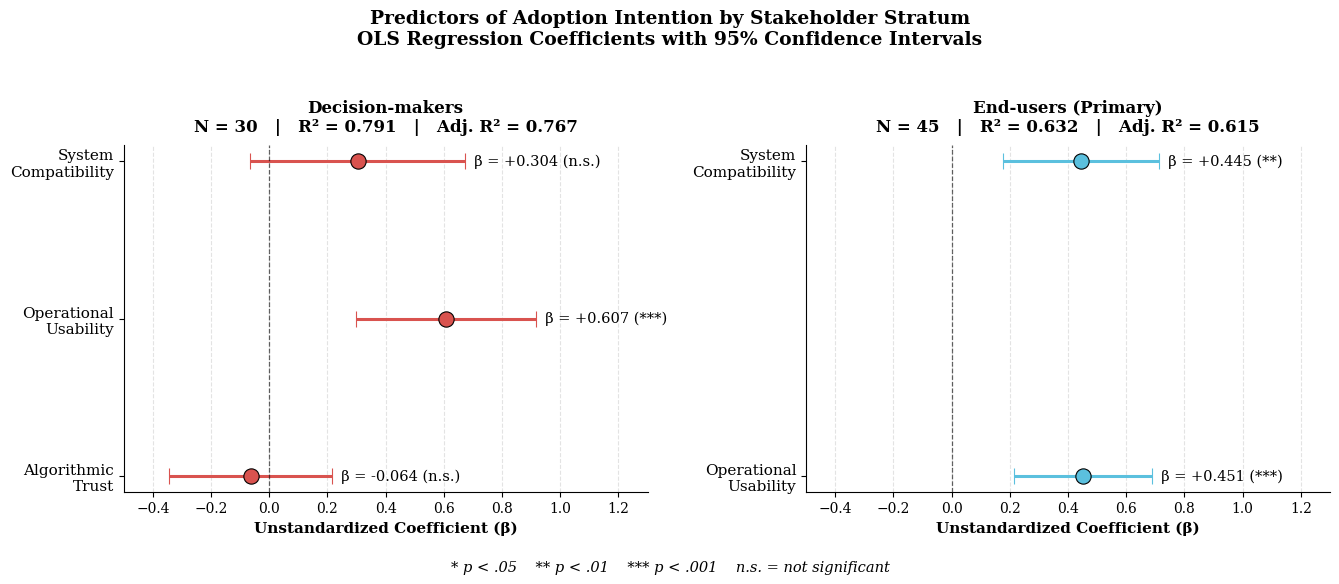


Saved: Figure_3_5_OLS_ForestPlot.png


In [ ]:
import matplotlib.pyplot as plt

# =====================================================================
# CELL 8 - 3.2.8. REGRESSION DIAGNOSTICS: VIF & FOREST PLOT
# Run AFTER survey.py (depends on: num, owner, emp)
# =====================================================================

# ---------------------------------------------------------------------
# PART A: VARIANCE INFLATION FACTOR (Multicollinearity Diagnostic)
# ---------------------------------------------------------------------
def compute_vif(data, predictors, label):
    """Compute VIF for each predictor; flag concern levels per Hair et al. (2019)."""
    d = data[predictors].dropna()
    X = sm.add_constant(d)
    vif_df = pd.DataFrame({
        'Predictor': predictors,
        'VIF': [variance_inflation_factor(X.values, i + 1)
                for i in range(len(predictors))]
    })
    vif_df['Interpretation'] = vif_df['VIF'].apply(
        lambda v: 'No concern (<5)' if v < 5
        else 'Moderate (5-10)' if v < 10
        else 'Severe (>10)'
    )
    print(f"\n--- VIF: {label} (N={len(d)}) ---")
    print(vif_df.round(3).to_string(index=False))
    return vif_df

print("=" * 70)
print("3.2.8  REGRESSION DIAGNOSTICS")
print("=" * 70)

vif_owner = compute_vif(num.loc[owner], ['SC_score', 'OU_score', 'AT_score'],
                        "Decision-makers (Full Model)")
vif_emp_primary = compute_vif(num.loc[emp], ['SC_score', 'OU_score'],
                              "End-users (Primary Model)")
vif_emp_ref = compute_vif(num.loc[emp], ['SC_score', 'OU_score', 'AT_score'],
                          "End-users (Reference Model with AT_EU)")

# Export consolidated VIF table for Chapter 3
vif_combined = pd.concat([
    vif_owner.assign(Model='Decision-makers'),
    vif_emp_primary.assign(Model='End-users (Primary)'),
    vif_emp_ref.assign(Model='End-users (Reference)')
])
vif_combined.to_csv('Table_3_18_VIF.csv', index=False, encoding='utf-8-sig')
print("\nSaved: Table_3_18_VIF.csv")

# ---------------------------------------------------------------------
# PART B: OLS RE-ESTIMATION WITH 95% CONFIDENCE INTERVALS
# ---------------------------------------------------------------------
def fit_ols_tidy(data, predictors, mask):
    """Fit OLS and return tidy coefficient table with 95% CI."""
    d = data.loc[mask, predictors + ['AI_score']].dropna()
    X = sm.add_constant(d[predictors])
    m = sm.OLS(d['AI_score'], X).fit()
    ci = m.conf_int(alpha=0.05)
    ci.columns = ['ci_low', 'ci_high']
    res = pd.DataFrame({
        'predictor': m.params.index,
        'beta': m.params.values,
        'se': m.bse.values,
        'p': m.pvalues.values,
        'ci_low': ci['ci_low'].values,
        'ci_high': ci['ci_high'].values
    })
    res = res[res['predictor'] != 'const'].reset_index(drop=True)
    return res, m

res_owner, m_owner = fit_ols_tidy(num, ['SC_score', 'OU_score', 'AT_score'], owner)
res_emp, m_emp = fit_ols_tidy(num, ['SC_score', 'OU_score'], emp)

print("\n--- Owner OLS coefficients with 95% CI ---")
print(res_owner.round(3).to_string(index=False))
print("\n--- Employee OLS coefficients with 95% CI ---")
print(res_emp.round(3).to_string(index=False))

# ---------------------------------------------------------------------
# PART C: FOREST PLOT (Figure 3.5)
# ---------------------------------------------------------------------
plt.rcParams['font.family'] = 'serif'

LABEL_MAP = {
    'SC_score': 'System\nCompatibility',
    'OU_score': 'Operational\nUsability',
    'AT_score': 'Algorithmic\nTrust'
}

def sig_marker(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'n.s.'

def draw_forest(ax, results, title, n_obs, r2, adj_r2, color):
    y_pos = np.arange(len(results))[::-1]   # reverse so first predictor sits on top
    err_low = results['beta'] - results['ci_low']
    err_high = results['ci_high'] - results['beta']

    ax.errorbar(results['beta'], y_pos,
                xerr=[err_low, err_high],
                fmt='o', color=color, ecolor=color,
                capsize=6, markersize=11, linewidth=2.2,
                markeredgecolor='black', markeredgewidth=0.8)

    # Annotate each point with beta and significance
    for i, (b, p, ch) in enumerate(zip(results['beta'],
                                       results['p'],
                                       results['ci_high'])):
        ax.annotate(f'  β = {b:+.3f} ({sig_marker(p)})',
                    xy=(ch, y_pos[i]),
                    va='center', fontsize=10.5)

    ax.axvline(0, color='black', linestyle='--', linewidth=0.9, alpha=0.6)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([LABEL_MAP[p] for p in results['predictor']], fontsize=11)
    ax.set_xlabel('Unstandardized Coefficient (β)', fontsize=11, fontweight='bold')
    ax.set_title(f'{title}\nN = {n_obs}   |   R² = {r2:.3f}   |   Adj. R² = {adj_r2:.3f}',
                 fontsize=12, fontweight='bold', pad=10)
    ax.grid(True, axis='x', linestyle='--', alpha=0.35)
    ax.set_xlim(-0.5, 1.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), sharex=True)

draw_forest(axes[0], res_owner, 'Decision-makers',
            int(m_owner.nobs), m_owner.rsquared, m_owner.rsquared_adj,
            color='#d9534f')
draw_forest(axes[1], res_emp, 'End-users (Primary)',
            int(m_emp.nobs), m_emp.rsquared, m_emp.rsquared_adj,
            color='#5bc0de')

fig.suptitle('Predictors of Adoption Intention by Stakeholder Stratum\n'
             'OLS Regression Coefficients with 95% Confidence Intervals',
             fontsize=13.5, fontweight='bold', y=1.04)

fig.text(0.5, -0.04,
         '* p < .05    ** p < .01    *** p < .001    n.s. = not significant',
         ha='center', fontsize=10.5, style='italic')

plt.tight_layout()
plt.savefig('Figure_3_5_OLS_ForestPlot.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nSaved: Figure_3_5_OLS_ForestPlot.png")